# Thai Typing Time-Series Transformation and Pilot Visualization

This notebook implements the preparation pipeline from raw browser textarea diff logs to transformed tables that are ready for downstream time-series mining.

Outputs created here:
- `event_sequence_enriched`
- `prompt_character_reference`
- `prompt_position_features`
- `error_episode_summary`
- `trial_qc`
- `session_qc`
- `trial_features`
- `participant_keyboard_profile`
- narrow sequence-ready exports for later DTW / Matrix Profile work

The focus here is transformation, quality checking, and pilot inspection. Final DTW / Matrix Profile / clustering analysis is intentionally deferred.


## Working Assumptions

- The interface is intended to allow append-only typing and pop-only deletion.
- The notebook audits those constraints instead of assuming they always hold.
- Keyboard burden uses the provided character map and keyboard distance matrix only. No `(x, y)` geometry is used.
- Punctuation and symbols default to English layout for prompt-demand joins.
- `PRACTICE` is recovered from pooled logs when it is missing from the main prompt table.
- Raw trial/session CSVs are optional. If they are absent, the notebook still runs from the pooled event log and keeps QC fields explicit about what could and could not be checked.

Throughout the transformation, the core interpretation is:

```text
current_text = correct_prefix + wrong_suffix
```


In [11]:
from __future__ import annotations

from glob import glob
from pathlib import Path
import math
import pickle
import warnings

from matplotlib import font_manager
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:  # pragma: no cover - notebook convenience fallback
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 140)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False

plt.rcParams["axes.spines.right"] = False

THAI_FONT_CANDIDATES = [
    "TH Sarabun New",
    "TH SarabunPSK",
    "Noto Sans Thai",
    "Noto Serif Thai",
    "Sarabun",
    "Garuda",
    "Loma",
    "Kinnari",
    "Norasi",
]


def configure_matplotlib_for_thai(candidates: list[str] = THAI_FONT_CANDIDATES) -> str | None:
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans", "Arial Unicode MS", "sans-serif"]
            plt.rcParams["axes.unicode_minus"] = False
            print(f"Thai plotting font in use: {font_name}")
            return font_name

    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "sans-serif"]
    plt.rcParams["axes.unicode_minus"] = False
    warnings.warn(
        "No Thai-capable matplotlib font was found. Install TH Sarabun New, TH SarabunPSK, or Noto Sans Thai for correct Thai plot rendering."
    )
    print("Thai plotting font in use: default matplotlib sans-serif (Thai-capable font not found)")
    return None


THAI_PLOT_FONT = configure_matplotlib_for_thai()

PROJECT_ROOT = Path.cwd()

RAW_EDIT_LOG_PATH = PROJECT_ROOT / "data" / "combined_edit_event_logs_data.csv"
RAW_TRIAL_LOG_PATH = PROJECT_ROOT / "data" / "trial_log*.csv"
RAW_SESSION_PATH = PROJECT_ROOT / "data" / "participant_session*.csv"
PROMPT_TABLE_PATH = PROJECT_ROOT / "thai_typing_prompts.csv"
CHARACTER_MAP_PATH = PROJECT_ROOT / "character_map_table_comprehensive.csv"
KEYBOARD_DISTANCE_MATRIX_PATH = PROJECT_ROOT / "Key_Distance_Matrix" / "dist_mat.pkl"
KEYBOARD_ADJACENCY_MATRIX_PATH = PROJECT_ROOT / "Key_Distance_Matrix" / "adj_mat.pkl"
PROJECT_CONTEXT_MD_PATH = PROJECT_ROOT / "project_context_comprehensive.md"
TRANSFORMATION_CONTEXT_MD_PATH = PROJECT_ROOT / "data_preparation_and_time_series_transformation.md"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "01_time_series_transformation_and_pilot_visualization"

INCLUDE_PRACTICE_TRIAL = True
EXPORT_PARQUET_WHEN_AVAILABLE = False
NEAR_KEY_DISTANCE_THRESHOLD = 1.0
PAUSE_THRESHOLDS_MS = (500, 1000, 2000)
SELECTED_PILOT_PROMPT_ID = "P14"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PILOT_FIGURE_DIR = OUTPUT_DIR / "figures"
PILOT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT


Thai plotting font in use: TH Sarabun New


PosixPath('/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis')

In [12]:
TRIAL_KEY_COLS = ["session_id", "participant_code", "trial_index", "trial_type", "prompt_id"]

REQUIRED_EVENT_COLUMNS = [
    "session_id",
    "participant_code",
    "trial_index",
    "trial_type",
    "prompt_id",
    "event_index",
    "event_time_ms_from_prompt_start",
    "action_type",
    "diff_start_index",
    "deleted_text",
    "inserted_text",
    "deleted_length",
    "inserted_length",
    "previous_text_length",
    "resulting_text_length",
    "selection_start_before",
    "selection_end_before",
    "selection_start_after",
    "selection_end_after",
]

STANDARD_PHYSICAL_KEY_TO_KEYCODE = {
    "Backquote": 192,
    "Digit1": 49,
    "Digit2": 50,
    "Digit3": 51,
    "Digit4": 52,
    "Digit5": 53,
    "Digit6": 54,
    "Digit7": 55,
    "Digit8": 56,
    "Digit9": 57,
    "Digit0": 48,
    "Minus": 189,
    "Equal": 187,
    "KeyQ": 81,
    "KeyW": 87,
    "KeyE": 69,
    "KeyR": 82,
    "KeyT": 84,
    "KeyY": 89,
    "KeyU": 85,
    "KeyI": 73,
    "KeyO": 79,
    "KeyP": 80,
    "BracketLeft": 219,
    "BracketRight": 221,
    "Backslash": 220,
    "KeyA": 65,
    "KeyS": 83,
    "KeyD": 68,
    "KeyF": 70,
    "KeyG": 71,
    "KeyH": 72,
    "KeyJ": 74,
    "KeyK": 75,
    "KeyL": 76,
    "Semicolon": 186,
    "Quote": 222,
    "KeyZ": 90,
    "KeyX": 88,
    "KeyC": 67,
    "KeyV": 86,
    "KeyB": 66,
    "KeyN": 78,
    "KeyM": 77,
    "Comma": 188,
    "Period": 190,
    "Slash": 191,
    "Space": 32,
}

CHAR_MAP_META_COLS = [
    "char",
    "map_id",
    "unicode_codepoint",
    "unicode_name",
    "script_family",
    "char_class",
    "layout_required",
    "shift_required",
    "preferred_for_prompt_demand",
    "physical_key_id",
    "distance_node_id",
    "key_row",
    "key_column_index",
    "zone_proxy",
    "hand_proxy",
    "is_space",
    "is_thai_script",
    "is_english_script",
    "is_punctuation_or_symbol",
    "project_layout_preference",
    "char_map_candidate_count",
    "char_map_top_rule_candidate_count",
    "char_map_ambiguous",
    "char_map_rule_tied",
    "char_map_resolution_note",
    "char_map_resolved_with_fallback",
]

KEY_ROW_ORDER = {"number": 0, "top": 1, "home": 2, "bottom": 3, "space": 4}


def expand_paths(path_like: Path | str | None) -> list[Path]:
    if path_like is None:
        return []
    text = str(path_like)
    if any(token in text for token in "*?[]"):
        return [Path(item) for item in sorted(glob(text))]
    path = Path(text)
    return [path] if path.exists() else []


def load_csv_bundle(path_like: Path | str | None, label: str, required: bool = False) -> pd.DataFrame:
    paths = expand_paths(path_like)
    if not paths:
        if required:
            raise FileNotFoundError(f"{label}: no files found for {path_like}")
        print(f"{label}: no files found for {path_like}")
        return pd.DataFrame()

    frames = []
    for path in paths:
        frame = pd.read_csv(path)
        frame["__source_file"] = path.name
        frame["__source_path"] = str(path)
        frames.append(frame)

    loaded = pd.concat(frames, ignore_index=True, sort=False)
    print(f"{label}: loaded {len(loaded):,} rows from {len(paths)} file(s)")
    return loaded


def load_pickle(path: Path):
    with open(path, "rb") as handle:
        return pickle.load(handle)


def validate_required_columns(df: pd.DataFrame, required_columns: list[str], label: str) -> None:
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"{label} is missing required columns: {missing}")


def safe_text(value) -> str:
    return "" if pd.isna(value) else str(value)


def longest_common_prefix_len(left, right):
    if pd.isna(left) or pd.isna(right):
        return np.nan
    left = str(left)
    right = str(right)
    limit = min(len(left), len(right))
    idx = 0
    while idx < limit and left[idx] == right[idx]:
        idx += 1
    return idx


def safe_zscore(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().sum() == 0:
        return pd.Series(np.nan, index=series.index)
    mean = numeric.mean(skipna=True)
    std = numeric.std(skipna=True, ddof=0)
    if pd.isna(std) or std == 0:
        result = pd.Series(0.0, index=series.index)
        result[numeric.isna()] = np.nan
        return result
    return (numeric - mean) / std


def lookup_char(text, pos):
    if pd.isna(text) or pd.isna(pos):
        return pd.NA
    pos = int(pos)
    text = str(text)
    if pos < 0 or pos >= len(text):
        return pd.NA
    return text[pos]


def neutral_layout_switch(prev_layout, next_layout):
    if pd.isna(prev_layout) or pd.isna(next_layout):
        return np.nan
    if prev_layout == "COMMON" or next_layout == "COMMON":
        return 0
    return int(prev_layout != next_layout)


def stringify_profile_value(value) -> str:
    if pd.isna(value):
        return "<missing>"
    if isinstance(value, (bool, np.bool_)):
        return str(int(value))
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, float) and value.is_integer():
        return str(int(value))
    return str(value)


def save_table(df: pd.DataFrame, stem: str, output_dir: Path = OUTPUT_DIR, index: bool = False) -> dict:
    csv_path = output_dir / f"{stem}.csv"
    df.to_csv(csv_path, index=index)
    saved = {"csv": str(csv_path)}

    if EXPORT_PARQUET_WHEN_AVAILABLE:
        parquet_path = output_dir / f"{stem}.parquet"
        try:
            df.to_parquet(parquet_path, index=index)
            saved["parquet"] = str(parquet_path)
        except Exception as exc:  # pragma: no cover - environment dependent
            saved["parquet"] = f"skipped ({exc.__class__.__name__}: {exc})"
    return saved


In [13]:
def infer_project_layout_preference(char) -> str | float:
    if pd.isna(char):
        return np.nan
    char = str(char)
    if char == " ":
        return "COMMON"
    if len(char) != 1:
        return np.nan
    codepoint = ord(char)
    if char.isdigit():
        return "EN"
    if "A" <= char <= "Z" or "a" <= char <= "z":
        return "EN"
    if 0x0E00 <= codepoint <= 0x0E7F:
        return "TH"
    return "EN"


def recover_practice_prompt_text(edit_df: pd.DataFrame):
    practice = edit_df.loc[edit_df["prompt_id"].eq("PRACTICE")].copy()
    if practice.empty:
        return None, "no_practice_rows"

    practice = practice.sort_values(TRIAL_KEY_COLS + ["event_index"])
    final_texts = []

    for _, grp in practice.groupby(TRIAL_KEY_COLS, sort=False):
        text = ""
        for row in grp.itertuples(index=False):
            if row.action_type == "insert":
                text = text + safe_text(row.inserted_text)
            elif row.action_type == "delete":
                deleted_text = safe_text(row.deleted_text)
                text = text[:-len(deleted_text)] if deleted_text else text
        final_texts.append(text)

    finals = pd.Series(final_texts, dtype="object")
    if finals.empty or finals.mode().empty:
        return None, "unable_to_recover"

    dominant = finals.mode().iloc[0]
    consensus = finals.eq(dominant).mean()
    status = "consensus" if consensus == 1 else f"mode_{consensus:.1%}"
    return dominant, status


def build_prompt_table_with_practice(prompt_df: pd.DataFrame, edit_df: pd.DataFrame, include_practice: bool = True) -> pd.DataFrame:
    prompt_df = prompt_df.copy()
    prompt_df["prompt_source"] = "prompt_table"

    if include_practice and "PRACTICE" not in set(prompt_df["prompt_id"]):
        practice_text, recovery_status = recover_practice_prompt_text(edit_df)
        if practice_text:
            practice_row = {
                "prompt_id": "PRACTICE",
                "prompt_typing_order": 0,
                "length_class": "practice",
                "condition": "practice_warmup",
                "purpose": "Recovered from pooled practice trials because the main prompt table stores only main prompts.",
                "expected_typing_behavior": "warmup / interface familiarization",
                "prompt_text": practice_text,
                "prompt_source": f"recovered_from_event_log_{recovery_status}",
            }
            prompt_df = pd.concat([pd.DataFrame([practice_row]), prompt_df], ignore_index=True)

    prompt_df["prompt_length"] = prompt_df["prompt_text"].astype(str).str.len()
    prompt_df = prompt_df.sort_values(["prompt_typing_order", "prompt_id"]).reset_index(drop=True)
    return prompt_df


def resolve_character_map(char_map_df: pd.DataFrame):
    work = char_map_df.copy()
    work["project_layout_preference"] = work["char"].map(infer_project_layout_preference)
    work["key_row_rank"] = work["key_row"].map(KEY_ROW_ORDER).fillna(99)

    resolved_rows = []
    audit_rows = []

    for char, grp in work.groupby("char", dropna=False, sort=True):
        grp = grp.copy()
        preferred_layout = infer_project_layout_preference(char)
        grp["score_layout"] = grp["layout_required"].eq(preferred_layout).astype(int)
        grp["score_preferred"] = pd.to_numeric(grp["preferred_for_prompt_demand"], errors="coerce").fillna(0).astype(int)

        top_mask = grp["score_layout"].eq(grp["score_layout"].max()) & grp["score_preferred"].eq(grp["score_preferred"].max())
        top_candidates = grp.loc[top_mask].copy()
        top_count = int(len(top_candidates))

        chosen = (
            top_candidates.sort_values(
                ["shift_required", "key_row_rank", "key_column_index", "physical_key_id", "map_id"],
                ascending=[True, True, True, True, True],
            )
            .iloc[0]
            .copy()
        )

        if len(grp) == 1:
            resolution_note = "unique"
        elif top_count == 1:
            resolution_note = "project_rule_resolved"
        else:
            resolution_note = "deterministic_fallback_after_tie"

        chosen["project_layout_preference"] = preferred_layout
        chosen["char_map_candidate_count"] = len(grp)
        chosen["char_map_top_rule_candidate_count"] = top_count
        chosen["char_map_ambiguous"] = int(len(grp) > 1)
        chosen["char_map_rule_tied"] = int(top_count > 1)
        chosen["char_map_resolution_note"] = resolution_note
        chosen["char_map_resolved_with_fallback"] = int(top_count > 1)
        resolved_rows.append(chosen)

        audit_rows.append(
            {
                "char": char,
                "project_layout_preference": preferred_layout,
                "char_map_candidate_count": len(grp),
                "char_map_top_rule_candidate_count": top_count,
                "chosen_map_id": chosen["map_id"],
                "chosen_physical_key_id": chosen["physical_key_id"],
                "resolution_note": resolution_note,
            }
        )

    resolved = pd.DataFrame(resolved_rows).drop(columns=["score_layout", "score_preferred", "key_row_rank"], errors="ignore")
    audit = pd.DataFrame(audit_rows).sort_values(
        ["char_map_candidate_count", "char_map_top_rule_candidate_count", "char"],
        ascending=[False, False, True],
    )
    return resolved.reset_index(drop=True), audit.reset_index(drop=True)


def build_keyboard_lookup(char_map_df: pd.DataFrame, distance_matrix, adjacency_matrix=None) -> pd.DataFrame:
    nodes = (
        char_map_df[["distance_node_id", "physical_key_id"]]
        .drop_duplicates()
        .rename(columns={"distance_node_id": "node_id"})
        .sort_values("node_id")
        .reset_index(drop=True)
    )
    nodes["keycode"] = nodes["node_id"].map(STANDARD_PHYSICAL_KEY_TO_KEYCODE)

    missing_nodes = nodes.loc[nodes["keycode"].isna(), "node_id"].tolist()
    if missing_nodes:
        raise ValueError(f"Missing keycode mapping for distance nodes: {missing_nodes}")

    records = []
    for src in nodes.itertuples(index=False):
        for tgt in nodes.itertuples(index=False):
            src_code = int(src.keycode)
            tgt_code = int(tgt.keycode)
            distance = distance_matrix[src_code][tgt_code]
            is_adjacent = adjacency_matrix[src_code][tgt_code] if adjacency_matrix is not None else int(distance == 1)
            records.append(
                {
                    "source_node_id": src.node_id,
                    "target_node_id": tgt.node_id,
                    "source_physical_key_id": src.physical_key_id,
                    "target_physical_key_id": tgt.physical_key_id,
                    "source_keycode": src_code,
                    "target_keycode": tgt_code,
                    "distance": distance,
                    "is_adjacent": int(is_adjacent),
                }
            )

    lookup = pd.DataFrame(records)
    lookup["distance"] = pd.to_numeric(lookup["distance"], errors="coerce").replace([np.inf, -np.inf], np.nan)
    return lookup


def lookup_distance(source_node, target_node, distance_lookup: dict):
    if pd.isna(source_node) or pd.isna(target_node):
        return np.nan
    return distance_lookup.get((source_node, target_node), np.nan)


def lookup_adjacency(source_node, target_node, adjacency_lookup: dict):
    if pd.isna(source_node) or pd.isna(target_node):
        return np.nan
    return adjacency_lookup.get((source_node, target_node), np.nan)


def attach_character_metadata(df: pd.DataFrame, left_col: str, prefix: str, resolved_char_map: pd.DataFrame) -> pd.DataFrame:
    meta = resolved_char_map[CHAR_MAP_META_COLS].copy()
    rename_map = {"char": left_col}
    rename_map.update({column: f"{prefix}_{column}" for column in CHAR_MAP_META_COLS if column != "char"})
    meta = meta.rename(columns=rename_map)
    return df.merge(meta, on=left_col, how="left")


def build_prompt_character_reference(prompt_df: pd.DataFrame, resolved_char_map: pd.DataFrame, distance_lookup: dict) -> pd.DataFrame:
    rows = []
    for prompt in prompt_df.itertuples(index=False):
        if pd.isna(prompt.prompt_text):
            continue
        for pos, char in enumerate(str(prompt.prompt_text)):
            rows.append(
                {
                    "prompt_id": prompt.prompt_id,
                    "prompt_typing_order": prompt.prompt_typing_order,
                    "length_class": prompt.length_class,
                    "condition": prompt.condition,
                    "prompt_source": prompt.prompt_source,
                    "prompt_position": pos,
                    "prompt_position_1based": pos + 1,
                    "char_j": char,
                    "prev_char_j": str(prompt.prompt_text)[pos - 1] if pos > 0 else pd.NA,
                }
            )

    reference = pd.DataFrame(rows)

    current_meta = resolved_char_map[CHAR_MAP_META_COLS].copy().rename(
        columns={**{"char": "char_j"}, **{column: f"{column}_j" for column in CHAR_MAP_META_COLS if column != "char"}}
    )
    prev_meta = resolved_char_map[CHAR_MAP_META_COLS].copy().rename(
        columns={**{"char": "prev_char_j"}, **{column: f"prev_{column}_j" for column in CHAR_MAP_META_COLS if column != "char"}}
    )

    reference = reference.merge(current_meta, on="char_j", how="left")
    reference = reference.merge(prev_meta, on="prev_char_j", how="left")

    reference["distance_from_prev_correct_j"] = [
        lookup_distance(prev_node, curr_node, distance_lookup)
        for prev_node, curr_node in zip(reference["prev_distance_node_id_j"], reference["distance_node_id_j"])
    ]
    reference["layout_switch_into_j"] = [
        neutral_layout_switch(prev_layout, curr_layout)
        for prev_layout, curr_layout in zip(reference["prev_layout_required_j"], reference["layout_required_j"])
    ]
    reference["distance_from_prev_bin_j"] = pd.cut(
        reference["distance_from_prev_correct_j"],
        bins=[-0.1, 1, 2, np.inf],
        labels=["low", "medium", "high"],
    )
    return reference


In [14]:
def prepare_edit_events(edit_df: pd.DataFrame) -> pd.DataFrame:
    validate_required_columns(edit_df, REQUIRED_EVENT_COLUMNS, "Raw edit log")

    work = edit_df.copy()
    work["deleted_text"] = work["deleted_text"].map(safe_text)
    work["inserted_text"] = work["inserted_text"].map(safe_text)

    numeric_cols = [
        "trial_index",
        "event_index",
        "event_time_ms_from_prompt_start",
        "diff_start_index",
        "deleted_length",
        "inserted_length",
        "previous_text_length",
        "resulting_text_length",
        "selection_start_before",
        "selection_end_before",
        "selection_start_after",
        "selection_end_after",
    ]
    for column in numeric_cols:
        work[column] = pd.to_numeric(work[column], errors="coerce")

    work["trial_uid"] = (
        work["session_id"].astype(str)
        + "__"
        + work["trial_index"].astype("Int64").astype(str)
        + "__"
        + work["prompt_id"].astype(str)
    )

    work = work.sort_values(TRIAL_KEY_COLS + ["event_index"]).reset_index(drop=True)
    return work


def build_event_enriched(
    edit_df: pd.DataFrame,
    prompt_df: pd.DataFrame,
    resolved_char_map: pd.DataFrame,
    distance_lookup: dict,
    adjacency_lookup: dict,
):
    work = prepare_edit_events(edit_df)

    prompt_cols = [
        "prompt_id",
        "prompt_typing_order",
        "length_class",
        "condition",
        "purpose",
        "expected_typing_behavior",
        "prompt_text",
        "prompt_source",
        "prompt_length",
    ]
    work = work.merge(prompt_df[prompt_cols], on="prompt_id", how="left", validate="m:1")

    event_tables = []
    trial_qc_rows = []

    for _, grp in work.groupby(TRIAL_KEY_COLS, sort=False):
        grp = grp.sort_values("event_index").copy()
        text = ""
        prev_time = None
        row_records = []

        qc_event_index_ok = bool(grp["event_index"].iloc[0] == 1 and grp["event_index"].diff().fillna(1).eq(1).all())
        qc_time_monotonic_ok = bool(grp["event_time_ms_from_prompt_start"].diff().fillna(0).ge(0).all())

        for _, row in grp.iterrows():
            record = row.to_dict()
            text_before = text
            insert_text = safe_text(row["inserted_text"])
            delete_text = safe_text(row["deleted_text"])
            diff_start = int(row["diff_start_index"])
            delete_length = int(row["deleted_length"])
            insert_length = int(row["inserted_length"])

            is_insert = row["action_type"] == "insert"
            is_delete = row["action_type"] == "delete"

            append_like = is_insert and diff_start == len(text_before) and delete_length == 0
            pop_like = is_delete and diff_start == len(text_before) - delete_length and insert_length == 0 and text_before.endswith(delete_text)

            if append_like:
                text_after = text_before + insert_text
                reconstruction_strategy = "append"
                violation_type = "none"
            elif pop_like:
                text_after = text_before[:-delete_length] if delete_length else text_before
                reconstruction_strategy = "pop"
                violation_type = "none"
            else:
                start = max(diff_start, 0)
                end = max(diff_start + delete_length, 0)
                text_after = text_before[:start] + insert_text + text_before[end:]
                reconstruction_strategy = "generic_diff_patch"
                if row["action_type"] not in {"insert", "delete"}:
                    violation_type = "unsupported_action"
                elif is_insert:
                    violation_type = "non_terminal_insert"
                elif is_delete:
                    violation_type = "non_pop_delete"
                else:
                    violation_type = "unexpected_edit_pattern"

            row_length_formula_ok = (
                int(row["previous_text_length"]) - int(row["deleted_length"]) + int(row["inserted_length"])
                == int(row["resulting_text_length"])
            )
            row_length_matches_text_ok = len(text_before) == int(row["previous_text_length"]) and len(text_after) == int(row["resulting_text_length"])
            deleted_text_matches_before = text_before[diff_start : diff_start + delete_length] == delete_text if delete_length else True
            selection_collapsed_ok = (
                int(row["selection_start_before"]) == int(row["selection_end_before"])
                and int(row["selection_start_after"]) == int(row["selection_end_after"])
            )
            selection_end_caret_ok = (
                int(row["selection_end_before"]) == int(row["previous_text_length"])
                and int(row["selection_end_after"]) == int(row["resulting_text_length"])
            )

            dt_ms = np.nan if prev_time is None else row["event_time_ms_from_prompt_start"] - prev_time
            dt_ms_filled = row["event_time_ms_from_prompt_start"] if pd.isna(dt_ms) else dt_ms

            record.update(
                {
                    "text_before": text_before,
                    "text_after": text_after,
                    "text_before_length_actual": len(text_before),
                    "text_after_length_actual": len(text_after),
                    "reconstruction_strategy": reconstruction_strategy,
                    "event_obeys_append_pop": int(append_like or pop_like),
                    "append_pop_violation_type": violation_type,
                    "row_length_formula_ok": int(row_length_formula_ok),
                    "row_length_matches_text_ok": int(row_length_matches_text_ok),
                    "deleted_text_matches_before": int(deleted_text_matches_before),
                    "selection_collapsed_ok": int(selection_collapsed_ok),
                    "selection_end_caret_ok": int(selection_end_caret_ok),
                    "row_reconstruction_ok": int(
                        row_length_formula_ok
                        and row_length_matches_text_ok
                        and deleted_text_matches_before
                        and selection_collapsed_ok
                        and selection_end_caret_ok
                    ),
                    "dt_ms": dt_ms,
                    "dt_ms_filled": dt_ms_filled,
                    "log_dt_ms": np.log1p(dt_ms_filled) if pd.notna(dt_ms_filled) else np.nan,
                    "is_insert": int(is_insert),
                    "is_delete": int(is_delete),
                    "insert_len": insert_length,
                    "delete_len": delete_length,
                    "net_len_change": insert_length - delete_length,
                    "is_backspace_like": int(is_delete and delete_length > 0 and insert_length == 0),
                }
            )
            row_records.append(record)

            text = text_after
            prev_time = row["event_time_ms_from_prompt_start"]

        trial_events = pd.DataFrame(row_records)

        target_text = trial_events["prompt_text"].iloc[0] if "prompt_text" in trial_events.columns else pd.NA
        target_text = target_text if pd.notna(target_text) else pd.NA
        target_length = len(target_text) if pd.notna(target_text) else np.nan

        trial_events["prefix_match_len_before"] = [
            longest_common_prefix_len(text_before, target_text) if pd.notna(target_text) else np.nan
            for text_before in trial_events["text_before"]
        ]
        trial_events["prefix_match_len_after"] = [
            longest_common_prefix_len(text_after, target_text) if pd.notna(target_text) else np.nan
            for text_after in trial_events["text_after"]
        ]
        trial_events["prefix_gain"] = trial_events["prefix_match_len_after"] - trial_events["prefix_match_len_before"]
        trial_events["error_suffix_len_before"] = trial_events["text_before"].str.len() - trial_events["prefix_match_len_before"]
        trial_events["error_suffix_len_after"] = trial_events["text_after"].str.len() - trial_events["prefix_match_len_after"]
        trial_events["error_suffix_delta"] = trial_events["error_suffix_len_after"] - trial_events["error_suffix_len_before"]
        trial_events["remaining_len_after"] = (
            target_length - trial_events["prefix_match_len_after"] if pd.notna(target_length) else np.nan
        )
        trial_events["is_progress"] = (trial_events["prefix_gain"] > 0).astype(int)
        trial_events["is_regress"] = (trial_events["prefix_gain"] < 0).astype(int)
        trial_events["is_stall"] = (trial_events["prefix_gain"] == 0).astype(int)
        trial_events["in_error_state_before"] = (trial_events["error_suffix_len_before"] > 0).astype(int)
        trial_events["in_error_state_after"] = (trial_events["error_suffix_len_after"] > 0).astype(int)
        trial_events["delete_after_error"] = (
            trial_events["is_delete"].eq(1) & trial_events["error_suffix_len_before"].gt(0)
        ).astype(int)
        trial_events["is_recovery_step"] = (
            trial_events["error_suffix_len_before"].gt(0)
            & (
                trial_events["error_suffix_len_after"].lt(trial_events["error_suffix_len_before"])
                | trial_events["prefix_gain"].gt(0)
            )
        ).astype(int)

        error_mask = trial_events["error_suffix_len_after"].gt(0)
        episode_start = error_mask & ~error_mask.shift(fill_value=False)
        trial_events["error_episode_id"] = episode_start.cumsum().where(error_mask, pd.NA).astype("Int64")

        trial_events["prev_correct_pos"] = pd.Series(
            [value - 1 if pd.notna(value) and value > 0 else pd.NA for value in trial_events["prefix_match_len_before"]],
            dtype="Int64",
        )
        trial_events["expected_pos"] = pd.Series(
            [
                value if pd.notna(value) and pd.notna(target_length) and value < target_length else pd.NA
                for value in trial_events["prefix_match_len_before"]
            ],
            dtype="Int64",
        )
        trial_events["expected_pos_1based"] = pd.Series(
            [value + 1 if pd.notna(value) else pd.NA for value in trial_events["expected_pos"]],
            dtype="Int64",
        )
        trial_events["prev_correct_char"] = [
            lookup_char(target_text, pos) if pd.notna(target_text) else pd.NA for pos in trial_events["prev_correct_pos"]
        ]
        trial_events["expected_char"] = [
            lookup_char(target_text, pos) if pd.notna(target_text) else pd.NA for pos in trial_events["expected_pos"]
        ]
        trial_events["correct_prefix_before"] = [
            target_text[: int(prefix)] if pd.notna(target_text) and pd.notna(prefix) else pd.NA
            for prefix in trial_events["prefix_match_len_before"]
        ]
        trial_events["correct_prefix_after"] = [
            target_text[: int(prefix)] if pd.notna(target_text) and pd.notna(prefix) else pd.NA
            for prefix in trial_events["prefix_match_len_after"]
        ]
        trial_events["wrong_suffix_before"] = [
            text_before[int(prefix) :] if pd.notna(prefix) else pd.NA
            for text_before, prefix in zip(trial_events["text_before"], trial_events["prefix_match_len_before"])
        ]
        trial_events["wrong_suffix_after"] = [
            text_after[int(prefix) :] if pd.notna(prefix) else pd.NA
            for text_after, prefix in zip(trial_events["text_after"], trial_events["prefix_match_len_after"])
        ]
        trial_events["time_to_next_event_ms"] = (
            trial_events["event_time_ms_from_prompt_start"].shift(-1) - trial_events["event_time_ms_from_prompt_start"]
        ).fillna(0)
        for threshold in PAUSE_THRESHOLDS_MS:
            trial_events[f"is_pause_{threshold}"] = trial_events["dt_ms_filled"].ge(threshold).astype(int)

        trial_core_qc_ok = bool(
            pd.notna(target_text)
            and qc_event_index_ok
            and qc_time_monotonic_ok
            and trial_events["event_obeys_append_pop"].eq(1).all()
            and trial_events["row_reconstruction_ok"].eq(1).all()
        )
        final_text = trial_events["text_after"].iloc[-1]
        final_exact_match = bool(pd.notna(target_text) and final_text == target_text)

        trial_events["qc_prompt_available_ok"] = int(pd.notna(target_text))
        trial_events["qc_event_index_ok"] = int(qc_event_index_ok)
        trial_events["qc_time_monotonic_ok"] = int(qc_time_monotonic_ok)
        trial_events["qc_append_pop_ok"] = int(trial_events["event_obeys_append_pop"].eq(1).all())
        trial_events["qc_reconstruction_ok"] = int(trial_events["row_reconstruction_ok"].eq(1).all())
        trial_events["qc_exact_match_ok"] = int(final_exact_match)
        trial_events["qc_trial_core_ok"] = int(trial_core_qc_ok)

        trial_qc_rows.append(
            {
                "trial_uid": trial_events["trial_uid"].iloc[0],
                "session_id": trial_events["session_id"].iloc[0],
                "participant_code": trial_events["participant_code"].iloc[0],
                "trial_index": trial_events["trial_index"].iloc[0],
                "trial_type": trial_events["trial_type"].iloc[0],
                "prompt_id": trial_events["prompt_id"].iloc[0],
                "prompt_typing_order": trial_events["prompt_typing_order"].iloc[0],
                "length_class": trial_events["length_class"].iloc[0],
                "condition": trial_events["condition"].iloc[0],
                "prompt_source": trial_events["prompt_source"].iloc[0],
                "prompt_text": target_text,
                "prompt_length": target_length,
                "event_count": len(trial_events),
                "final_reconstructed_text": final_text,
                "final_prefix_match_len": trial_events["prefix_match_len_after"].iloc[-1],
                "final_resulting_text_length": trial_events["text_after"].str.len().iloc[-1],
                "qc_prompt_available_ok": int(pd.notna(target_text)),
                "qc_event_index_ok": int(qc_event_index_ok),
                "qc_time_monotonic_ok": int(qc_time_monotonic_ok),
                "qc_append_pop_ok": int(trial_events["event_obeys_append_pop"].eq(1).all()),
                "qc_reconstruction_ok": int(trial_events["row_reconstruction_ok"].eq(1).all()),
                "qc_exact_match_ok": int(final_exact_match),
                "all_core_qc_ok": int(trial_core_qc_ok),
            }
        )

        event_tables.append(trial_events)

    event_enriched = pd.concat(event_tables, ignore_index=True, sort=False)
    trial_qc = pd.DataFrame(trial_qc_rows)

    event_enriched = attach_character_metadata(event_enriched, "prev_correct_char", "prev", resolved_char_map)
    event_enriched = attach_character_metadata(event_enriched, "expected_char", "expected", resolved_char_map)

    event_enriched["layout_switch_needed"] = [
        neutral_layout_switch(prev_layout, expected_layout)
        for prev_layout, expected_layout in zip(
            event_enriched["prev_layout_required"], event_enriched["expected_layout_required"]
        )
    ]
    event_enriched["shift_transition"] = [
        (
            np.nan
            if pd.isna(prev_shift) or pd.isna(expected_shift) or pd.isna(prev_layout) or pd.isna(expected_layout)
            else int(prev_shift != expected_shift)
        )
        for prev_shift, expected_shift, prev_layout, expected_layout in zip(
            event_enriched["prev_shift_required"],
            event_enriched["expected_shift_required"],
            event_enriched["prev_layout_required"],
            event_enriched["expected_layout_required"],
        )
    ]
    event_enriched["target_key_distance"] = [
        lookup_distance(prev_node, expected_node, distance_lookup)
        for prev_node, expected_node in zip(
            event_enriched["prev_distance_node_id"], event_enriched["expected_distance_node_id"]
        )
    ]
    event_enriched["target_key_is_adjacent"] = [
        lookup_adjacency(prev_node, expected_node, adjacency_lookup)
        for prev_node, expected_node in zip(
            event_enriched["prev_distance_node_id"], event_enriched["expected_distance_node_id"]
        )
    ]
    event_enriched["same_key_transition"] = (
        event_enriched["target_key_distance"].fillna(np.inf).eq(0)
    ).astype(int)
    event_enriched["same_hand_transition"] = (
        event_enriched["prev_hand_proxy"].notna()
        & event_enriched["expected_hand_proxy"].notna()
        & event_enriched["prev_hand_proxy"].eq(event_enriched["expected_hand_proxy"])
    ).astype(int)
    event_enriched["zone_transition"] = [
        f"{prev_zone}->{expected_zone}" if pd.notna(prev_zone) and pd.notna(expected_zone) else pd.NA
        for prev_zone, expected_zone in zip(event_enriched["prev_zone_proxy"], event_enriched["expected_zone_proxy"])
    ]

    insert_differs_from_expected = pd.Series(
        [
            safe_text(inserted_char) != safe_text(expected_char)
            for inserted_char, expected_char in zip(event_enriched["inserted_text"], event_enriched["expected_char"])
        ],
        index=event_enriched.index,
    )

    event_enriched["wrong_char"] = np.where(
        event_enriched["is_insert"].eq(1)
        & event_enriched["insert_len"].eq(1)
        & event_enriched["expected_char"].notna()
        & event_enriched["prefix_gain"].le(0)
        & insert_differs_from_expected,
        event_enriched["inserted_text"],
        pd.NA,
    )
    event_enriched = attach_character_metadata(event_enriched, "wrong_char", "wrong", resolved_char_map)

    different_layout_from_target = pd.Series(
        [
            pd.notna(wrong_layout)
            and pd.notna(expected_layout)
            and safe_text(wrong_layout) != safe_text(expected_layout)
            for wrong_layout, expected_layout in zip(
                event_enriched["wrong_layout_required"], event_enriched["expected_layout_required"]
            )
        ],
        index=event_enriched.index,
    )
    same_layout_as_target = pd.Series(
        [
            pd.notna(wrong_layout)
            and pd.notna(expected_layout)
            and safe_text(wrong_layout) == safe_text(expected_layout)
            for wrong_layout, expected_layout in zip(
                event_enriched["wrong_layout_required"], event_enriched["expected_layout_required"]
            )
        ],
        index=event_enriched.index,
    )
    different_shift_from_target = pd.Series(
        [
            pd.notna(wrong_shift) and pd.notna(expected_shift) and float(wrong_shift) != float(expected_shift)
            for wrong_shift, expected_shift in zip(
                pd.to_numeric(event_enriched["wrong_shift_required"], errors="coerce"),
                pd.to_numeric(event_enriched["expected_shift_required"], errors="coerce"),
            )
        ],
        index=event_enriched.index,
    )

    event_enriched["error_to_target_distance"] = [
        lookup_distance(wrong_node, expected_node, distance_lookup)
        for wrong_node, expected_node in zip(
            event_enriched["wrong_distance_node_id"], event_enriched["expected_distance_node_id"]
        )
    ]
    same_key_family = (
        event_enriched["wrong_physical_key_id"].notna()
        & event_enriched["expected_physical_key_id"].notna()
        & event_enriched["wrong_physical_key_id"].eq(event_enriched["expected_physical_key_id"])
    )
    event_enriched["is_layout_confusion"] = (
        event_enriched["wrong_char"].notna()
        & same_key_family
        & event_enriched["wrong_layout_required"].notna()
        & event_enriched["expected_layout_required"].notna()
        & different_layout_from_target
    ).astype(int)
    event_enriched["is_shift_confusion"] = (
        event_enriched["wrong_char"].notna()
        & same_key_family
        & same_layout_as_target
        & event_enriched["wrong_shift_required"].notna()
        & event_enriched["expected_shift_required"].notna()
        & different_shift_from_target
    ).astype(int)
    event_enriched["is_near_key_typo"] = (
        event_enriched["wrong_char"].notna()
        & event_enriched["error_to_target_distance"].notna()
        & event_enriched["error_to_target_distance"].le(NEAR_KEY_DISTANCE_THRESHOLD)
        & event_enriched["is_layout_confusion"].eq(0)
        & event_enriched["is_shift_confusion"].eq(0)
    ).astype(int)
    event_enriched["is_far_error"] = (
        event_enriched["wrong_char"].notna()
        & event_enriched["error_to_target_distance"].notna()
        & event_enriched["error_to_target_distance"].gt(NEAR_KEY_DISTANCE_THRESHOLD)
        & event_enriched["is_layout_confusion"].eq(0)
        & event_enriched["is_shift_confusion"].eq(0)
    ).astype(int)

    event_enriched["z_log_dt_ms"] = safe_zscore(event_enriched["log_dt_ms"])
    event_enriched["z_error_suffix_len_after"] = safe_zscore(event_enriched["error_suffix_len_after"])
    event_enriched["z_target_key_distance"] = safe_zscore(event_enriched["target_key_distance"])
    event_enriched["geo_burden_planned"] = (
        event_enriched["z_target_key_distance"].fillna(0)
        + pd.to_numeric(event_enriched["layout_switch_needed"], errors="coerce").fillna(0)
        + pd.to_numeric(event_enriched["expected_shift_required"], errors="coerce").fillna(0)
    )
    event_enriched["z_geo_burden_planned"] = safe_zscore(event_enriched["geo_burden_planned"])

    event_enriched["z_error_to_target_distance"] = safe_zscore(event_enriched["error_to_target_distance"])
    event_enriched["geo_burden_error"] = (
        event_enriched["z_error_to_target_distance"].fillna(0)
        + event_enriched["is_layout_confusion"].fillna(0)
        + event_enriched["is_shift_confusion"].fillna(0)
    )
    event_enriched["z_geo_burden_error"] = safe_zscore(event_enriched["geo_burden_error"])

    event_enriched["friction"] = (
        0.30 * event_enriched["z_log_dt_ms"].fillna(0)
        + 0.25 * event_enriched["is_delete"].fillna(0)
        + 0.30 * event_enriched["z_error_suffix_len_after"].fillna(0)
        + 0.08 * event_enriched["z_geo_burden_planned"].fillna(0)
        + 0.02 * pd.to_numeric(event_enriched["layout_switch_needed"], errors="coerce").fillna(0)
    )

    event_enriched = event_enriched.sort_values(["trial_uid", "event_index"]).copy()
    event_enriched["friction_plot_smooth"] = (
        event_enriched.groupby("trial_uid", sort=False)["friction"]
        .transform(lambda s: s.rolling(window=5, center=True, min_periods=1).mean())
    )

    event_enriched["target_distance_bin"] = pd.cut(
        event_enriched["target_key_distance"], bins=[-0.1, 1, 2, np.inf], labels=["low", "medium", "high"]
    )
    event_enriched["error_distance_bin"] = pd.cut(
        event_enriched["error_to_target_distance"], bins=[-0.1, 1, 2, np.inf], labels=["low", "medium", "high"]
    )

    return event_enriched, trial_qc


def merge_optional_trial_log(trial_qc: pd.DataFrame, raw_trial_df: pd.DataFrame) -> pd.DataFrame:
    if raw_trial_df.empty:
        return trial_qc

    merge_keys = [column for column in TRIAL_KEY_COLS if column in raw_trial_df.columns and column in trial_qc.columns]
    if not merge_keys:
        return trial_qc

    candidate_columns = [
        column
        for column in raw_trial_df.columns
        if column in merge_keys or column in {"typed_text_final", "exact_match", "first_key_latency_ms", "trial_duration_ms"}
    ]
    merged_trial_log = raw_trial_df[candidate_columns].drop_duplicates(merge_keys)
    output = trial_qc.merge(merged_trial_log, on=merge_keys, how="left")

    if "typed_text_final" in output.columns:
        output["qc_trial_log_final_text_match"] = np.where(
            output["typed_text_final"].notna(),
            output["typed_text_final"].eq(output["final_reconstructed_text"]).astype(int),
            pd.NA,
        )
    if "exact_match" in output.columns:
        output["qc_trial_log_exact_match_agrees"] = np.where(
            output["exact_match"].notna(),
            output["exact_match"].astype(str).str.lower().isin({"1", "true", "yes"}).eq(output["qc_exact_match_ok"].eq(1)).astype(int),
            pd.NA,
        )
    return output


def build_session_qc(trial_qc: pd.DataFrame, prompt_df: pd.DataFrame, raw_session_df: pd.DataFrame) -> pd.DataFrame:
    expected_main_prompt_ids = (
        prompt_df.loc[prompt_df["prompt_id"].ne("PRACTICE")]
        .sort_values("prompt_typing_order")["prompt_id"]
        .tolist()
    )

    rows = []
    for session_id, grp in trial_qc.groupby("session_id", sort=False):
        main_trials = grp.loc[grp["trial_type"].eq("main")].sort_values("trial_index")
        observed_main_prompt_ids = main_trials["prompt_id"].tolist()

        rows.append(
            {
                "session_id": session_id,
                "participant_code": grp["participant_code"].iloc[0],
                "n_trials_observed": len(grp),
                "n_main_trials_observed": len(main_trials),
                "has_practice_trial": int(grp["trial_type"].eq("practice").any()),
                "qc_main_prompt_count_ok": int(len(observed_main_prompt_ids) == len(expected_main_prompt_ids)),
                "qc_main_prompt_ids_complete": int(set(observed_main_prompt_ids) == set(expected_main_prompt_ids)),
                "qc_main_prompt_order_ok": int(observed_main_prompt_ids == expected_main_prompt_ids),
                "qc_all_trial_core_ok": int(grp["all_core_qc_ok"].eq(1).all()),
            }
        )

    session_qc = pd.DataFrame(rows)

    if not raw_session_df.empty and "session_id" in raw_session_df.columns:
        candidate_columns = [
            column
            for column in raw_session_df.columns
            if column
            in {
                "session_id",
                "participant_code",
                "consent_acknowledged",
                "main_prompt_count_expected",
                "main_prompt_count_completed",
                "total_duration_ms",
                "started_at_iso",
                "completed_at_iso",
            }
        ]
        session_qc = session_qc.merge(
            raw_session_df[candidate_columns].drop_duplicates("session_id"),
            on=["session_id"] + (["participant_code"] if "participant_code" in candidate_columns else []),
            how="left",
        )

        if {"main_prompt_count_expected", "main_prompt_count_completed"} <= set(session_qc.columns):
            session_qc["qc_session_count_fields_agree"] = np.where(
                session_qc["main_prompt_count_expected"].notna() & session_qc["main_prompt_count_completed"].notna(),
                session_qc["main_prompt_count_expected"].eq(session_qc["main_prompt_count_completed"]).astype(int),
                pd.NA,
            )
        if "consent_acknowledged" in session_qc.columns:
            session_qc["qc_consent_acknowledged"] = session_qc["consent_acknowledged"]

    return session_qc


def build_error_episode_summary(event_enriched: pd.DataFrame) -> pd.DataFrame:
    episodes = event_enriched.loc[event_enriched["error_episode_id"].notna()].copy()
    if episodes.empty:
        return pd.DataFrame()

    rows = []
    group_cols = TRIAL_KEY_COLS + ["trial_uid", "error_episode_id"]

    for _, grp in episodes.groupby(group_cols, sort=False):
        delete_steps = grp.loc[grp["is_delete"].eq(1)]
        rows.append(
            {
                "trial_uid": grp["trial_uid"].iloc[0],
                "session_id": grp["session_id"].iloc[0],
                "participant_code": grp["participant_code"].iloc[0],
                "trial_index": grp["trial_index"].iloc[0],
                "trial_type": grp["trial_type"].iloc[0],
                "prompt_id": grp["prompt_id"].iloc[0],
                "error_episode_id": grp["error_episode_id"].iloc[0],
                "episode_start_event_index": grp["event_index"].min(),
                "episode_end_event_index": grp["event_index"].max(),
                "episode_start_time_ms": grp["event_time_ms_from_prompt_start"].min(),
                "episode_end_time_ms": grp["event_time_ms_from_prompt_start"].max(),
                "episode_duration_ms": grp["event_time_ms_from_prompt_start"].max() - grp["event_time_ms_from_prompt_start"].min(),
                "episode_event_count": len(grp),
                "episode_delete_count": grp["is_delete"].sum(),
                "episode_recovery_step_count": grp["is_recovery_step"].sum(),
                "max_error_suffix_depth": grp["error_suffix_len_after"].max(),
                "mean_friction": grp["friction"].mean(),
                "pause_before_first_delete_ms": delete_steps["dt_ms_filled"].iloc[0] if not delete_steps.empty else np.nan,
            }
        )

    return pd.DataFrame(rows)


def build_prompt_position_features(event_enriched: pd.DataFrame, prompt_character_reference: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, trial_events in event_enriched.groupby(TRIAL_KEY_COLS + ["trial_uid"], sort=False):
        prompt_id = trial_events["prompt_id"].iloc[0]
        prompt_reference = prompt_character_reference.loc[prompt_character_reference["prompt_id"].eq(prompt_id)].copy()
        if prompt_reference.empty:
            continue

        final_prefix = trial_events["prefix_match_len_after"].iloc[-1]

        for position_row in prompt_reference.itertuples(index=False):
            position = int(position_row.prompt_position)
            threshold = position + 1
            correct_after = trial_events["prefix_match_len_after"].ge(threshold)
            ever_typed = trial_events["resulting_text_length"].ge(threshold)

            time_to_first_correct = (
                trial_events.loc[correct_after, "event_time_ms_from_prompt_start"].min() if correct_after.any() else np.nan
            )
            suffix_all_true = correct_after.iloc[::-1].cummin().iloc[::-1]
            stable_mask = correct_after & suffix_all_true
            time_to_stability = (
                trial_events.loc[stable_mask, "event_time_ms_from_prompt_start"].min() if stable_mask.any() else np.nan
            )
            revisions = int((correct_after.shift(fill_value=False) & ~correct_after).sum())
            if ever_typed.any():
                first_typed_idx = ever_typed.idxmax()
                wrong_first = int(not bool(correct_after.loc[first_typed_idx]))
            else:
                wrong_first = np.nan

            position_events = trial_events.loc[trial_events["expected_pos"].eq(position)]

            rows.append(
                {
                    "trial_uid": trial_events["trial_uid"].iloc[0],
                    "session_id": trial_events["session_id"].iloc[0],
                    "participant_code": trial_events["participant_code"].iloc[0],
                    "trial_index": trial_events["trial_index"].iloc[0],
                    "trial_type": trial_events["trial_type"].iloc[0],
                    "prompt_id": prompt_id,
                    "prompt_typing_order": trial_events["prompt_typing_order"].iloc[0],
                    "length_class": trial_events["length_class"].iloc[0],
                    "condition": trial_events["condition"].iloc[0],
                    "prompt_position": position,
                    "prompt_position_1based": position + 1,
                    "time_to_first_correct_ms": time_to_first_correct,
                    "time_to_stability_ms": time_to_stability,
                    "revisions": revisions,
                    "wrong_first": wrong_first,
                    "local_event_count": len(position_events),
                    "local_mean_dt_ms": position_events["dt_ms_filled"].mean(),
                    "local_max_dt_ms": position_events["dt_ms_filled"].max(),
                    "local_mean_friction": position_events["friction"].mean(),
                    "final_position_correct": int(final_prefix >= threshold),
                }
            )

    features = pd.DataFrame(rows)
    features = features.merge(
        prompt_character_reference,
        on=["prompt_id", "prompt_typing_order", "length_class", "condition", "prompt_position", "prompt_position_1based"],
        how="left",
    )
    return features


def build_trial_features(event_enriched: pd.DataFrame, trial_qc: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, grp in event_enriched.groupby(TRIAL_KEY_COLS + ["trial_uid"], sort=False):
        rows.append(
            {
                "trial_uid": grp["trial_uid"].iloc[0],
                "session_id": grp["session_id"].iloc[0],
                "participant_code": grp["participant_code"].iloc[0],
                "trial_index": grp["trial_index"].iloc[0],
                "trial_type": grp["trial_type"].iloc[0],
                "prompt_id": grp["prompt_id"].iloc[0],
                "prompt_typing_order": grp["prompt_typing_order"].iloc[0],
                "length_class": grp["length_class"].iloc[0],
                "condition": grp["condition"].iloc[0],
                "duration_ms": grp["event_time_ms_from_prompt_start"].max(),
                "first_key_latency_ms": grp["event_time_ms_from_prompt_start"].iloc[0],
                "event_count": len(grp),
                "insert_count": grp["is_insert"].sum(),
                "delete_count": grp["is_delete"].sum(),
                "mean_dt_ms": grp["dt_ms_filled"].mean(),
                "median_dt_ms": grp["dt_ms_filled"].median(),
                "mean_friction": grp["friction"].mean(),
                "max_friction": grp["friction"].max(),
                "total_time_in_error_ms": grp.loc[grp["in_error_state_after"].eq(1), "time_to_next_event_ms"].sum(),
                "number_of_error_episodes": grp["error_episode_id"].nunique(dropna=True),
                "maximum_wrong_suffix_depth": grp["error_suffix_len_after"].max(),
                "mean_planned_geometry_burden": grp["geo_burden_planned"].mean(),
                "layout_switch_count": pd.to_numeric(grp["layout_switch_needed"], errors="coerce").fillna(0).sum(),
                "shift_required_count": pd.to_numeric(grp["expected_shift_required"], errors="coerce").fillna(0).sum(),
                "near_key_typo_count": grp["is_near_key_typo"].sum(),
                "layout_confusion_count": grp["is_layout_confusion"].sum(),
                "shift_confusion_count": grp["is_shift_confusion"].sum(),
            }
        )

    trial_features = pd.DataFrame(rows)
    merge_keys = TRIAL_KEY_COLS + ["trial_uid", "prompt_typing_order", "length_class", "condition"]
    merge_payload = merge_keys + [
        column for column in trial_qc.columns if column not in set(merge_keys) and column not in set(trial_features.columns)
    ]
    trial_features = trial_features.merge(trial_qc[merge_payload], on=merge_keys, how="left")
    return trial_features


def build_participant_keyboard_profile(
    event_enriched: pd.DataFrame,
    prompt_position_features: pd.DataFrame,
) -> pd.DataFrame:
    event_dimensions = [
        ("expected_layout", "expected_layout_required"),
        ("expected_shift_required", "expected_shift_required"),
        ("layout_switch_needed", "layout_switch_needed"),
        ("target_distance_bin", "target_distance_bin"),
        ("expected_char_class", "expected_char_class"),
        ("expected_zone_proxy", "expected_zone_proxy"),
        ("expected_hand_proxy", "expected_hand_proxy"),
    ]
    position_dimensions = [
        ("expected_layout", "layout_required_j"),
        ("expected_shift_required", "shift_required_j"),
        ("layout_switch_needed", "layout_switch_into_j"),
        ("target_distance_bin", "distance_from_prev_bin_j"),
        ("expected_char_class", "char_class_j"),
        ("expected_zone_proxy", "zone_proxy_j"),
        ("expected_hand_proxy", "hand_proxy_j"),
    ]

    profile_frames = []
    event_base = event_enriched.loc[event_enriched["expected_pos"].notna()].copy()
    position_base = prompt_position_features.copy()

    for (dimension_name, event_column), (_, position_column) in zip(event_dimensions, position_dimensions):
        event_part = (
            event_base.groupby(["participant_code", event_column], dropna=False)
            .agg(
                n_events=("event_index", "size"),
                n_trials_from_events=("trial_uid", "nunique"),
                mean_log_dt_ms=("log_dt_ms", "mean"),
                mean_friction=("friction", "mean"),
                delete_rate=("is_delete", "mean"),
                near_key_typo_rate=("is_near_key_typo", "mean"),
                layout_confusion_rate=("is_layout_confusion", "mean"),
                shift_confusion_rate=("is_shift_confusion", "mean"),
            )
            .reset_index()
            .rename(columns={event_column: "profile_value_raw"})
        )

        position_part = (
            position_base.groupby(["participant_code", position_column], dropna=False)
            .agg(
                n_positions=("prompt_position", "size"),
                n_trials_from_positions=("trial_uid", "nunique"),
                mean_time_to_first_correct_ms=("time_to_first_correct_ms", "mean"),
                mean_time_to_stability_ms=("time_to_stability_ms", "mean"),
                mean_revisions=("revisions", "mean"),
                wrong_first_rate=("wrong_first", "mean"),
            )
            .reset_index()
            .rename(columns={position_column: "profile_value_raw"})
        )

        merged = event_part.merge(position_part, on=["participant_code", "profile_value_raw"], how="outer")
        merged["profile_dimension"] = dimension_name
        merged["profile_value"] = merged["profile_value_raw"].map(stringify_profile_value)
        profile_frames.append(merged.drop(columns=["profile_value_raw"]))

    profile = pd.concat(profile_frames, ignore_index=True, sort=False)
    ordered_columns = [
        "participant_code",
        "profile_dimension",
        "profile_value",
        "n_events",
        "n_positions",
        "n_trials_from_events",
        "n_trials_from_positions",
        "mean_log_dt_ms",
        "mean_friction",
        "delete_rate",
        "near_key_typo_rate",
        "layout_confusion_rate",
        "shift_confusion_rate",
        "mean_time_to_first_correct_ms",
        "mean_time_to_stability_ms",
        "mean_revisions",
        "wrong_first_rate",
    ]
    remaining_columns = [column for column in profile.columns if column not in ordered_columns]
    return profile[ordered_columns + remaining_columns].sort_values(
        ["participant_code", "profile_dimension", "profile_value"]
    ).reset_index(drop=True)


## Friction Update

Canonical `friction` now uses a fixed weighted formula:

- `0.30 * z_log_dt_ms`
- `0.25 * is_delete`
- `0.30 * z_error_suffix_len_after`
- `0.08 * z_geo_burden_planned`
- `0.02 * layout_switch_needed`

`geo_burden_error` is intentionally excluded from canonical friction. `friction_plot_smooth` is a centered rolling mean with `window=5` and `min_periods=1`, computed within each trial for visualization only. Downstream modeling and exported analysis features should use canonical raw `friction`.

In [15]:
raw_edit_df = load_csv_bundle(RAW_EDIT_LOG_PATH, label="Edit-event log", required=True)
raw_trial_df = load_csv_bundle(RAW_TRIAL_LOG_PATH, label="Trial log", required=False)
raw_session_df = load_csv_bundle(RAW_SESSION_PATH, label="Session log", required=False)

prompt_df_main = pd.read_csv(PROMPT_TABLE_PATH)
character_map_raw = pd.read_csv(CHARACTER_MAP_PATH)
keyboard_distance_matrix = load_pickle(KEYBOARD_DISTANCE_MATRIX_PATH)
keyboard_adjacency_matrix = load_pickle(KEYBOARD_ADJACENCY_MATRIX_PATH) if KEYBOARD_ADJACENCY_MATRIX_PATH.exists() else None

prompt_df = build_prompt_table_with_practice(prompt_df_main, raw_edit_df, include_practice=INCLUDE_PRACTICE_TRIAL)
resolved_char_map, char_map_resolution_audit = resolve_character_map(character_map_raw)
keyboard_distance_lookup = build_keyboard_lookup(resolved_char_map, keyboard_distance_matrix, keyboard_adjacency_matrix)
distance_lookup = keyboard_distance_lookup.set_index(["source_node_id", "target_node_id"])["distance"].to_dict()
adjacency_lookup = keyboard_distance_lookup.set_index(["source_node_id", "target_node_id"])["is_adjacent"].to_dict()
prompt_character_reference = build_prompt_character_reference(prompt_df, resolved_char_map, distance_lookup)

reference_file_status = pd.DataFrame(
    [
        {"reference_file": "project_context_comprehensive.md", "exists": PROJECT_CONTEXT_MD_PATH.exists(), "path": str(PROJECT_CONTEXT_MD_PATH)},
        {
            "reference_file": "data_preparation_and_time_series_transformation.md",
            "exists": TRANSFORMATION_CONTEXT_MD_PATH.exists(),
            "path": str(TRANSFORMATION_CONTEXT_MD_PATH),
        },
        {"reference_file": "character_map_table_comprehensive.csv", "exists": CHARACTER_MAP_PATH.exists(), "path": str(CHARACTER_MAP_PATH)},
    ]
)

input_inventory = pd.DataFrame(
    [
        {"table": "raw_edit_df", "rows": len(raw_edit_df), "columns": raw_edit_df.shape[1]},
        {"table": "raw_trial_df", "rows": len(raw_trial_df), "columns": raw_trial_df.shape[1] if not raw_trial_df.empty else 0},
        {"table": "raw_session_df", "rows": len(raw_session_df), "columns": raw_session_df.shape[1] if not raw_session_df.empty else 0},
        {"table": "prompt_df", "rows": len(prompt_df), "columns": prompt_df.shape[1]},
        {"table": "character_map_raw", "rows": len(character_map_raw), "columns": character_map_raw.shape[1]},
        {"table": "resolved_char_map", "rows": len(resolved_char_map), "columns": resolved_char_map.shape[1]},
        {"table": "keyboard_distance_lookup", "rows": len(keyboard_distance_lookup), "columns": keyboard_distance_lookup.shape[1]},
        {"table": "prompt_character_reference", "rows": len(prompt_character_reference), "columns": prompt_character_reference.shape[1]},
    ]
)

display(reference_file_status)
display(input_inventory)
display(prompt_df.head(5))
display(char_map_resolution_audit.head(10))


Edit-event log: loaded 30,930 rows from 1 file(s)
Trial log: no files found for /Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/data/trial_log*.csv
Session log: no files found for /Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/data/participant_session*.csv


,reference_file,exists,path
0,project_context_comprehensive.md,False,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/project_context_comprehensive.md
1,data_preparation_and_time_series_transformation.md,False,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/data_preparation_and_time_series_transforma...
2,character_map_table_comprehensive.csv,True,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/character_map_table_comprehensive.csv


,table,rows,columns
0,raw_edit_df,30930,23
1,raw_trial_df,0,0
2,raw_session_df,0,0
3,prompt_df,15,9
4,character_map_raw,184,26
5,resolved_char_map,177,33
6,keyboard_distance_lookup,2304,8
7,prompt_character_reference,899,62


,prompt_id,prompt_typing_order,length_class,condition,purpose,expected_typing_behavior,prompt_text,prompt_source,prompt_length
0,PRACTICE,0,practice,practice_warmup,Recovered from pooled practice trials because the main prompt table stores only main prompts.,warmup / interface familiarization,วันนี้อากาศดีและฉันพร้อมเริ่มการทดลอง,recovered_from_event_log_consensus,37
1,P01,1,short,familiar_baseline,baseline familiar Thai,"smooth typing, low hesitation",วันนี้เราจะทำการบ้านให้เสร็จ,prompt_table,28
2,P02,2,short,familiar_polite,baseline polite everyday Thai,"mostly smooth typing, low hesitation",กรุณาตอบกลับภายในวันนี้,prompt_table,23
3,P04,3,short,orthographic_named_entity,test long proper noun typing difficulty,pause spikes and possible corrections,นิสิตจากจุฬาลงกรณ์มหาวิทยาลัย,prompt_table,29
4,P03,4,short,formal_register,test formal bureaucratic wording,"slightly slower rhythm, higher first-key latency",ขอความกรุณาจัดทำเอกสารดังกล่าว,prompt_table,30


,char,project_layout_preference,char_map_candidate_count,char_map_top_rule_candidate_count,chosen_map_id,chosen_physical_key_id,resolution_note
0,ม,TH,2,2,TH_KeyM_base,KeyM,deterministic_fallback_after_tie
1,"""",EN,2,1,EN_Quote_shift,Quote,project_rule_resolved
2,%,EN,2,1,EN_Digit5_shift,Digit5,project_rule_resolved
3,(,EN,2,1,EN_Digit9_shift,Digit9,project_rule_resolved
4,),EN,2,1,EN_Digit0_shift,Digit0,project_rule_resolved
5,",",EN,2,1,EN_Comma_base,Comma,project_rule_resolved
6,?,EN,2,1,EN_Slash_shift,Slash,project_rule_resolved
7,,COMMON,1,1,COMMON_Space,Space,unique
8,!,EN,1,1,EN_Digit1_shift,Digit1,unique
9,#,EN,1,1,EN_Digit3_shift,Digit3,unique


In [16]:
event_enriched, trial_qc = build_event_enriched(
    raw_edit_df,
    prompt_df,
    resolved_char_map,
    distance_lookup,
    adjacency_lookup,
)
trial_qc = merge_optional_trial_log(trial_qc, raw_trial_df)
session_qc = build_session_qc(trial_qc, prompt_df, raw_session_df)

qc_overview = pd.DataFrame(
    [
        {"metric": "sessions", "value": event_enriched["session_id"].nunique()},
        {"metric": "participants", "value": event_enriched["participant_code"].nunique()},
        {"metric": "trials", "value": trial_qc["trial_uid"].nunique()},
        {"metric": "events", "value": len(event_enriched)},
        {"metric": "core_trial_qc_pass_rate", "value": trial_qc["all_core_qc_ok"].mean()},
        {"metric": "exact_match_trial_rate", "value": trial_qc["qc_exact_match_ok"].mean()},
        {"metric": "append_pop_ok_rate", "value": trial_qc["qc_append_pop_ok"].mean()},
    ]
)

core_qc_columns = [
    "trial_uid",
    "participant_code",
    "prompt_id",
    "qc_prompt_available_ok",
    "qc_event_index_ok",
    "qc_time_monotonic_ok",
    "qc_append_pop_ok",
    "qc_reconstruction_ok",
    "qc_exact_match_ok",
    "all_core_qc_ok",
]
failed_trials = trial_qc.loc[trial_qc["all_core_qc_ok"].ne(1), core_qc_columns].copy()

display(qc_overview)
display(failed_trials.head(20))
display(event_enriched.head(10))


,metric,value
0,sessions,26.0
1,participants,26.0
2,trials,390.0
3,events,30930.0
4,core_trial_qc_pass_rate,1.0
5,exact_match_trial_rate,1.0
6,append_pop_ok_rate,1.0


,trial_uid,participant_code,prompt_id,qc_prompt_available_ok,qc_event_index_ok,qc_time_monotonic_ok,qc_append_pop_ok,qc_reconstruction_ok,qc_exact_match_ok,all_core_qc_ok


,session_id,participant_code,trial_index,trial_type,prompt_id,event_index,event_time_ms_from_prompt_start,action_type,diff_start_index,deleted_text,inserted_text,deleted_length,inserted_length,previous_text_length,resulting_text_length,selection_start_before,selection_end_before,selection_start_after,selection_end_after,source_folder,original_filename,__source_file,__source_path,trial_uid,prompt_typing_order,length_class,condition,purpose,expected_typing_behavior,prompt_text,prompt_source,prompt_length,text_before,text_after,text_before_length_actual,text_after_length_actual,reconstruction_strategy,event_obeys_append_pop,append_pop_violation_type,row_length_formula_ok,row_length_matches_text_ok,deleted_text_matches_before,selection_collapsed_ok,selection_end_caret_ok,row_reconstruction_ok,dt_ms,dt_ms_filled,log_dt_ms,is_insert,is_delete,insert_len,delete_len,net_len_change,is_backspace_like,prefix_match_len_before,prefix_match_len_after,prefix_gain,error_suffix_len_before,error_suffix_len_after,error_suffix_delta,remaining_len_after,is_progress,is_regress,is_stall,in_error_state_before,in_error_state_after,delete_after_error,is_recovery_step,error_episode_id,prev_correct_pos,expected_pos,expected_pos_1based,prev_correct_char,expected_char,correct_prefix_before,correct_prefix_after,wrong_suffix_before,wrong_suffix_after,time_to_next_event_ms,is_pause_500,is_pause_1000,is_pause_2000,qc_prompt_available_ok,qc_event_index_ok,qc_time_monotonic_ok,qc_append_pop_ok,qc_reconstruction_ok,qc_exact_match_ok,qc_trial_core_ok,prev_map_id,prev_unicode_codepoint,prev_unicode_name,prev_script_family,prev_char_class,prev_layout_required,prev_shift_required,prev_preferred_for_prompt_demand,prev_physical_key_id,prev_distance_node_id,prev_key_row,prev_key_column_index,prev_zone_proxy,prev_hand_proxy,prev_is_space,prev_is_thai_script,prev_is_english_script,prev_is_punctuation_or_symbol,prev_project_layout_preference,prev_char_map_candidate_count,prev_char_map_top_rule_candidate_count,prev_char_map_ambiguous,prev_char_map_rule_tied,prev_char_map_resolution_note,prev_char_map_resolved_with_fallback,expected_map_id,expected_unicode_codepoint,expected_unicode_name,expected_script_family,expected_char_class,expected_layout_required,expected_shift_required,expected_preferred_for_prompt_demand,expected_physical_key_id,expected_distance_node_id,expected_key_row,expected_key_column_index,expected_zone_proxy,expected_hand_proxy,expected_is_space,expected_is_thai_script,expected_is_english_script,expected_is_punctuation_or_symbol,expected_project_layout_preference,expected_char_map_candidate_count,expected_char_map_top_rule_candidate_count,expected_char_map_ambiguous,expected_char_map_rule_tied,expected_char_map_resolution_note,expected_char_map_resolved_with_fallback,layout_switch_needed,shift_transition,target_key_distance,target_key_is_adjacent,same_key_transition,same_hand_transition,zone_transition,wrong_char,wrong_map_id,wrong_unicode_codepoint,wrong_unicode_name,wrong_script_family,wrong_char_class,wrong_layout_required,wrong_shift_required,wrong_preferred_for_prompt_demand,wrong_physical_key_id,wrong_distance_node_id,wrong_key_row,wrong_key_column_index,wrong_zone_proxy,wrong_hand_proxy,wrong_is_space,wrong_is_thai_script,wrong_is_english_script,wrong_is_punctuation_or_symbol,wrong_project_layout_preference,wrong_char_map_candidate_count,wrong_char_map_top_rule_candidate_count,wrong_char_map_ambiguous,wrong_char_map_rule_tied,wrong_char_map_resolution_note,wrong_char_map_resolved_with_fallback,error_to_target_distance,is_layout_confusion,is_shift_confusion,is_near_key_typo,is_far_error,z_log_dt_ms,z_error_suffix_len_after,z_target_key_distance,geo_burden_planned,z_geo_burden_planned,z_error_to_target_distance,geo_burden_error,z_geo_burden_error,friction,friction_plot_smooth,target_distance_bin,error_distance_bin
0,20260419141512-jt34p4,ก้องฟ้า,0,practice,PRACTICE,1,1221,insert,0,,ว,0,1,0,1,0,0,1,1,thai-typing-study_ก้องฟ้า_20260419141512-jt34p4,edit_

In [17]:
error_episode_summary = build_error_episode_summary(event_enriched)
prompt_position_features = build_prompt_position_features(event_enriched, prompt_character_reference)
trial_features = build_trial_features(event_enriched, trial_qc)
participant_keyboard_profile = build_participant_keyboard_profile(event_enriched, prompt_position_features)

event_sequence_core = event_enriched[
    [
        "trial_uid",
        "session_id",
        "participant_code",
        "trial_index",
        "trial_type",
        "prompt_id",
        "event_index",
        "dt_ms_filled",
        "log_dt_ms",
        "is_delete",
        "prefix_gain",
        "error_suffix_len_after",
        "geo_burden_planned",
        "layout_switch_needed",
        "friction",
        "friction_plot_smooth",
    ]
].copy()

prompt_position_sequence_ready = prompt_position_features[
    [
        "trial_uid",
        "session_id",
        "participant_code",
        "trial_index",
        "trial_type",
        "prompt_id",
        "prompt_position",
        "prompt_position_1based",
        "time_to_first_correct_ms",
        "time_to_stability_ms",
        "revisions",
        "wrong_first",
    ]
].copy()

downstream_inventory = pd.DataFrame(
    [
        {"table": "event_enriched", "rows": len(event_enriched), "columns": event_enriched.shape[1]},
        {"table": "error_episode_summary", "rows": len(error_episode_summary), "columns": error_episode_summary.shape[1] if not error_episode_summary.empty else 0},
        {"table": "prompt_position_features", "rows": len(prompt_position_features), "columns": prompt_position_features.shape[1]},
        {"table": "trial_features", "rows": len(trial_features), "columns": trial_features.shape[1]},
        {"table": "participant_keyboard_profile", "rows": len(participant_keyboard_profile), "columns": participant_keyboard_profile.shape[1]},
        {"table": "event_sequence_core", "rows": len(event_sequence_core), "columns": event_sequence_core.shape[1]},
        {"table": "prompt_position_sequence_ready", "rows": len(prompt_position_sequence_ready), "columns": prompt_position_sequence_ready.shape[1]},
    ]
)

display(downstream_inventory)
display(prompt_position_features.head(10))
display(trial_features.head(10))
display(participant_keyboard_profile.head(10))


,table,rows,columns
0,event_enriched,30930,189
1,error_episode_summary,1889,18
2,prompt_position_features,23374,76
3,trial_features,390,40
4,participant_keyboard_profile,832,17
5,event_sequence_core,30930,16
6,prompt_position_sequence_ready,23374,12


,trial_uid,session_id,participant_code,trial_index,trial_type,prompt_id,prompt_typing_order,length_class,condition,prompt_position,prompt_position_1based,time_to_first_correct_ms,time_to_stability_ms,revisions,wrong_first,local_event_count,local_mean_dt_ms,local_max_dt_ms,local_mean_friction,final_position_correct,prompt_source,char_j,prev_char_j,map_id_j,unicode_codepoint_j,unicode_name_j,script_family_j,char_class_j,layout_required_j,shift_required_j,preferred_for_prompt_demand_j,physical_key_id_j,distance_node_id_j,key_row_j,key_column_index_j,zone_proxy_j,hand_proxy_j,is_space_j,is_thai_script_j,is_english_script_j,is_punctuation_or_symbol_j,project_layout_preference_j,char_map_candidate_count_j,char_map_top_rule_candidate_count_j,char_map_ambiguous_j,char_map_rule_tied_j,char_map_resolution_note_j,char_map_resolved_with_fallback_j,prev_map_id_j,prev_unicode_codepoint_j,prev_unicode_name_j,prev_script_family_j,prev_char_class_j,prev_layout_required_j,prev_shift_required_j,prev_preferred_for_prompt_demand_j,prev_physical_key_id_j,prev_distance_node_id_j,prev_key_row_j,prev_key_column_index_j,prev_zone_proxy_j,prev_hand_proxy_j,prev_is_space_j,prev_is_thai_script_j,prev_is_english_script_j,prev_is_punctuation_or_symbol_j,prev_project_layout_preference_j,prev_char_map_candidate_count_j,prev_char_map_top_rule_candidate_count_j,prev_char_map_ambiguous_j,prev_char_map_rule_tied_j,prev_char_map_resolution_note_j,prev_char_map_resolved_with_fallback_j,distance_from_prev_correct_j,layout_switch_into_j,distance_from_prev_bin_j
0,20260419141512-jt34p4__0__PRACTICE,20260419141512-jt34p4,ก้องฟ้า,0,practice,PRACTICE,0,practice,practice_warmup,0,1,1221,1221,0,0,1,1221.0,1221,0.487676,1,recovered_from_event_log_consensus,ว,<NA>,TH_Semicolon_base,U+0E27,THAI CHARACTER WO WAEN,thai,thai_consonant,TH,0.0,1.0,Semicolon,Semicolon,home,9.0,right,right,0.0,1.0,0.0,0.0,TH,1.0,1.0,0.0,0.0,unique,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20260419141512-jt34p4__0__PRACTICE,20260419141512-jt34p4,ก้องฟ้า,0,practice,PRACTICE,0,practice,practice_warmup,1,2,1317,1317,0,0,1,96.0,96,-0.366255,1,recovered_from_event_log_consensus,ั,ว,TH_KeyY_base,U+0E31,THAI CHARACTER MAI HAN-AKAT,thai,thai_vowel_mark,TH,0.0,1.0,KeyY,KeyY,top,5.0,center,right,0.0,1.0,0.0,0.0,TH,1.0,1.0,0.0,0.0,unique,0.0,TH_Semicolon_base,U+0E27,THAI CHARACTER WO WAEN,thai,thai_consonant,TH,0.0,1.0,Semicolon,Semicolon,home,9.0,right,right,0.0,1.0,0.0,0.0,TH,1.0,1.0,0.0,0.0,unique,0.0,4.0,0.0,high
2,20260419141512-jt34p4__0__PRACTICE,20260419141512-jt34p4,ก้องฟ้า,0,practice,PRACTICE,0,practice,practice_warmup,2,3,1385,1385,0,0,1,68.0,68,-0.526862,1,recovered_from_event_log_consensus,น,ั,TH_KeyO_base,U+0E19,THAI CHARACTER NO NU,thai,thai_consonant,TH,0.0,1.0,KeyO,KeyO,top,8.0,right,right,0.0,1.0,0.0,0.0,TH,1.0,1.0,0.0,0.0,unique,0.0,TH_KeyY_base,U+0E31,THAI CHARACTER MAI HAN-AKAT,thai,thai_vowel_mark,TH,0.0,1.0,KeyY,KeyY,top,5.0,center,right,0.0,1.0,0.0,0.0,TH,1.0,1.0,0.0,0.0,unique,0.0,3.0,0.0,high
3,20260419141512-jt34p4__0__PRACTICE,20260419141512-jt34p4,ก้องฟ้า,0,practice,PRACTICE,0,practice,practice_warmup,3,4,1544,1544,0,0,1,159.0,159,-0.355940,1,recovered_from_event_log_consensus,น,น,TH_KeyO_base,U+0E19,THAI CHARACTER NO NU,thai,thai_consonant,TH,0.0,1.0,KeyO,KeyO,top,8.0,right,right,0.0,1.0,0.0,0.0,TH,1.0,1.0,0.0,0.0,unique,0.0,TH_KeyO_base,U+0E19,THAI CHARACTER NO NU,thai,thai_consonant,TH,0.0,1.0,KeyO,KeyO,top,8.0,right,right,0.0,1.0,0.0,0.0,TH,1.0,1.0,0.0,0.0,unique,0.0,0.0,0.0,low
4,20260419141512-jt34p4__0__PRACTICE,20260419141512-jt34p4,ก้องฟ้า,0,practice,PRACTICE,0,practice,practice_warmup,4,5,1583,1583,0,0,1,39.0,39,-0.759168,1,recovered_from_event_log_consensus,ี,น,TH_KeyU_base,U+0E35,THAI CHARACTER SARA II,thai,thai_vowel_mark,TH,0.0,1.0,KeyU,KeyU,top,6.0,center,right,0.0,1.0,0.0,0.0,TH,1.0,1.0,0.0,0.0,unique,0.0,TH_KeyO_base,U+0E19,THAI CHARACTER NO NU,thai,thai_consonant,TH,0.0,1.0,KeyO,KeyO,top,8.

,trial_uid,session_id,participant_code,trial_index,trial_type,prompt_id,prompt_typing_order,length_class,condition,duration_ms,first_key_latency_ms,event_count,insert_count,delete_count,mean_dt_ms,median_dt_ms,mean_friction,max_friction,total_time_in_error_ms,number_of_error_episodes,maximum_wrong_suffix_depth,mean_planned_geometry_burden,layout_switch_count,shift_required_count,near_key_typo_count,layout_confusion_count,shift_confusion_count,prompt_source,prompt_text,prompt_length,final_reconstructed_text,final_prefix_match_len,final_resulting_text_length,qc_prompt_available_ok,qc_event_index_ok,qc_time_monotonic_ok,qc_append_pop_ok,qc_reconstruction_ok,qc_exact_match_ok,all_core_qc_ok
0,20260419141512-jt34p4__0__PRACTICE,20260419141512-jt34p4,ก้องฟ้า,0,practice,PRACTICE,0,practice,practice_warmup,7096,1221,37,37,0,191.783784,132.0,-0.239489,0.487676,0.0,0,0,0.220379,0.0,2.0,0,0,0,recovered_from_event_log_consensus,วันนี้อากาศดีและฉันพร้อมเริ่มการทดลอง,37,วันนี้อากาศดีและฉันพร้อมเริ่มการทดลอง,37,37,1,1,1,1,1,1,1
1,20260419141512-jt34p4__10__P08,20260419141512-jt34p4,ก้องฟ้า,10,main,P08,10,medium,formal_lexical_difficulty,11055,711,62,59,3,178.306452,147.0,-0.278895,0.419975,1253.0,1,3,-0.367548,0.0,1.0,1,0,0,prompt_table,ขอความร่วมมือจัดเตรียมเอกสารเพื่อเป็นวิทยาทานแก่นักเรียน,56,ขอความร่วมมือจัดเตรียมเอกสารเพื่อเป็นวิทยาทานแก่นักเรียน,56,56,1,1,1,1,1,1,1
2,20260419141512-jt34p4__11__P07,20260419141512-jt34p4,ก้องฟ้า,11,main,P07,11,medium,formal_educational,15943,762,78,72,6,204.397436,148.0,-0.214502,0.479295,2156.0,3,2,-0.173392,0.0,3.0,2,0,0,prompt_table,นักเรียนพึงศึกษาเล่าเรียนอย่างสม่ำเสมอเพื่อเตรียมความพร้อมในการสอบ,66,นักเรียนพึงศึกษาเล่าเรียนอย่างสม่ำเสมอเพื่อเตรียมความพร้อมในการสอบ,66,66,1,1,1,1,1,1,1
3,20260419141512-jt34p4__12__P12,20260419141512-jt34p4,ก้องฟ้า,12,main,P12,12,long,long_familiar_expository,28638,709,155,141,14,184.761290,161.0,-0.191559,0.573229,4942.0,7,3,0.191645,0.0,5.0,4,0,0,prompt_table,วันนี้ครูขอให้นักเรียนเขียนสรุปเรื่องสุภาษิตไทยอย่างกระชับและชัดเจน โดยให้ยกตัวอย่างหนึ่งสำนวนและอธิบายความหมายด้วยภาษาของตนเอง,127,วันนี้ครูขอให้นักเรียนเขียนสรุปเรื่องสุภาษิตไทยอย่างกระชับและชัดเจน โดยให้ยกตัวอย่างหนึ่งสำนวนและอธิบายความหมายด้วยภาษาของตนเอง,127,127,1,1,1,1,1,1,1
4,20260419141512-jt34p4__13__P14,20260419141512-jt34p4,ก้องฟ้า,13,main,P14,13,long,long_mixed_difficulty,38698,964,185,165,20,209.178378,160.0,-0.190206,0.728861,7002.0,9,4,-0.128401,0.0,16.0,5,0,1,prompt_table,สวัสดีคุณชาคริษฐ์ วันนี้เราขอให้คุณจัดทำหนังสือเรื่องการสอนภาษาไทยสำหรับนักเรียนชั้นมัธยมศึกษาปีที่ ๖ เพื่อเป็นวิทยาทานแก่โรงเรียนในเครื...,145,สวัสดีคุณชาคริษฐ์ วันนี้เราขอให้คุณจัดทำหนังสือเรื่องการสอนภาษาไทยสำหรับนักเรียนชั้นมัธยมศึกษาปีที่ ๖ เพื่อเป็นวิทยาทานแก่โรงเรียนในเครื...,145,145,1,1,1,1,1,1,1
5,20260419141512-jt34p4__14__P13,20260419141512-jt34p4,ก้องฟ้า,14,main,P13,14,long,long_formal_bureaucratic,31937,801,173,158,15,184.606936,162.0,-0.213432,0.510696,4583.0,7,3,0.087923,0.0,17.0,4,0,1,prompt_table,ทางคณะผู้จัดทำขอความกรุณาให้นักเรียนจัดทำรายงานเรื่องสุภาษิตและคำพังเพย โดยเขียนอธิบายเนื้อหาให้ครบถ้วนเพื่อเป็นประโยชน์ต่อการเรียนรู้ใน...,143,ทางคณะผู้จัดทำขอความกรุณาให้นักเรียนจัดทำรายงานเรื่องสุภาษิตและคำพังเพย โดยเขียนอธิบายเนื้อหาให้ครบถ้วนเพื่อเป็นประโยชน์ต่อการเรียนรู้ใน...,143,143,1,1,1,1,1,1,1
6,20260419141512-jt34p4__1__P01,20260419141512-jt34p4,ก้องฟ้า,1,main,P01,1,short,familiar_baseline,5297,671,28,28,0,189.178571,144.5,-0.293957,0.278145,0.0,0,0,-0.243586,0.0,1.0,0,0,0,prompt_table,วันนี้เราจะทำการบ้านให้เสร็จ,28,วันนี้เราจะทำการบ้านให้เสร็จ,28,28,1,1,1,1,1,1,1
7,20260419141512-jt34p4__2__P02,20260419141512-jt34p4,ก้องฟ้า,2,main,P02,2,short,familiar_polite,4030,695,23,23,0,175.217391,138.0,-0.239848,0.290441,0.0,0,0,0.258145,0.0,1.0,0,0,0,prompt_table,กรุณาตอบกลับภายในวันนี้,23,กรุณาตอบกลับภายในวันนี้,23,23,1,1,1,1,1,1,1
8,20260419141512-jt34p4__3__P04,20260419141512-jt34p4,ก้องฟ้า,3,main,P04,3,short,orthographic_named_entity,5907,718,31,30,1,190.548387,159.0,-0.182927,0.337714,279.0,1,1,0.344290,0.0,3.

,participant_code,profile_dimension,profile_value,n_events,n_positions,n_trials_from_events,n_trials_from_positions,mean_log_dt_ms,mean_friction,delete_rate,near_key_typo_rate,layout_confusion_rate,shift_confusion_rate,mean_time_to_first_correct_ms,mean_time_to_stability_ms,mean_revisions,wrong_first_rate
0,Bao,expected_char_class,<missing>,18,13,7,7,5.472382,-0.048073,0.111111,0.000000,0.000000,0.000000,23306.846154,23679.384615,0.076923,0.076923
1,Bao,expected_char_class,arabic_numeral,5,5,2,2,5.976598,0.152698,0.000000,0.000000,0.000000,0.000000,17189.600000,17189.600000,0.000000,0.000000
2,Bao,expected_char_class,english_punctuation,11,3,1,1,5.806234,0.389654,0.363636,0.000000,0.181818,0.000000,14106.000000,14106.000000,0.000000,0.666667
3,Bao,expected_char_class,thai_consonant,672,543,15,15,5.481696,-0.025286,0.087798,0.029762,0.014881,0.001488,24706.362799,25024.491713,0.023941,0.186004
4,Bao,expected_char_class,thai_diacritic,7,7,5,5,5.449982,0.000635,0.000000,0.000000,0.000000,0.000000,26138.428571,26138.428571,0.000000,0.142857
5,Bao,expected_char_class,thai_numeral,14,4,2,2,6.540939,0.485773,0.357143,0.000000,0.142857,0.000000,30309.250000,30309.250000,0.000000,0.750000
6,Bao,expected_char_class,thai_tone_mark,69,57,14,14,4.934596,-0.260529,0.101449,0.057971,0.000000,0.000000,25419.192982,25419.192982,0.000000,0.175439
7,Bao,expected_char_class,thai_vowel_mark,462,248,15,15,5.377636,0.079710,0.240260,0.054113,0.006494,0.000000,23174.125000,23361.112903,0.008065,0.201613
8,Bao,expected_char_class,whitespace,147,19,8,8,5.168878,2.053051,0.442177,0.000000,0.000000,0.000000,23031.526316,23031.526316,0.000000,0.263158
9,Bao,expected_hand_proxy,<missing>,18,13,7,7,5.472382,-0.048073,0.111111,0.000000,0.000000,0.000000,23306.846154,23679.384615,0.076923,0.076923


In [18]:
export_manifest = []

table_exports = {
    "char_map_resolution_audit": char_map_resolution_audit,
    "keyboard_distance_lookup": keyboard_distance_lookup,
    "prompt_character_reference": prompt_character_reference,
    "event_sequence_enriched": event_enriched,
    "event_sequence_core": event_sequence_core,
    "error_episode_summary": error_episode_summary,
    "prompt_position_features": prompt_position_features,
    "prompt_position_sequence_ready": prompt_position_sequence_ready,
    "trial_qc": trial_qc,
    "session_qc": session_qc,
    "trial_features": trial_features,
    "participant_keyboard_profile": participant_keyboard_profile,
}

for stem, table in table_exports.items():
    saved = save_table(table, stem)
    export_manifest.append(
        {
            "table": stem,
            "rows": len(table),
            "csv_path": saved["csv"],
            "parquet_path": saved.get("parquet", ""),
        }
    )

export_manifest = pd.DataFrame(export_manifest)
display(export_manifest)


,table,rows,csv_path,parquet_path
0,char_map_resolution_audit,177,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
1,keyboard_distance_lookup,2304,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
2,prompt_character_reference,899,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
3,event_sequence_enriched,30930,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
4,event_sequence_core,30930,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
5,error_episode_summary,1889,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
6,prompt_position_features,23374,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
7,prompt_position_sequence_ready,23374,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
8,trial_qc,390,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
9,session_qc,26,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,


## Deferred Extensions

The tables exported above are the intended starting point for later DTW, Matrix Profile, subsequence anomaly analysis, and participant clustering.

This notebook deliberately stops at:
- raw-log validation
- text-state reconstruction
- target alignment
- keyboard-demand augmentation
- prompt-position / trial / participant summaries
- pilot visualization

That keeps the transformation layer inspectable and debuggable before any heavier time-series mining choices are frozen.


Saved pilot figure to /Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_pilot_visualization/figures/pilot_trace_P14_DDDD.png


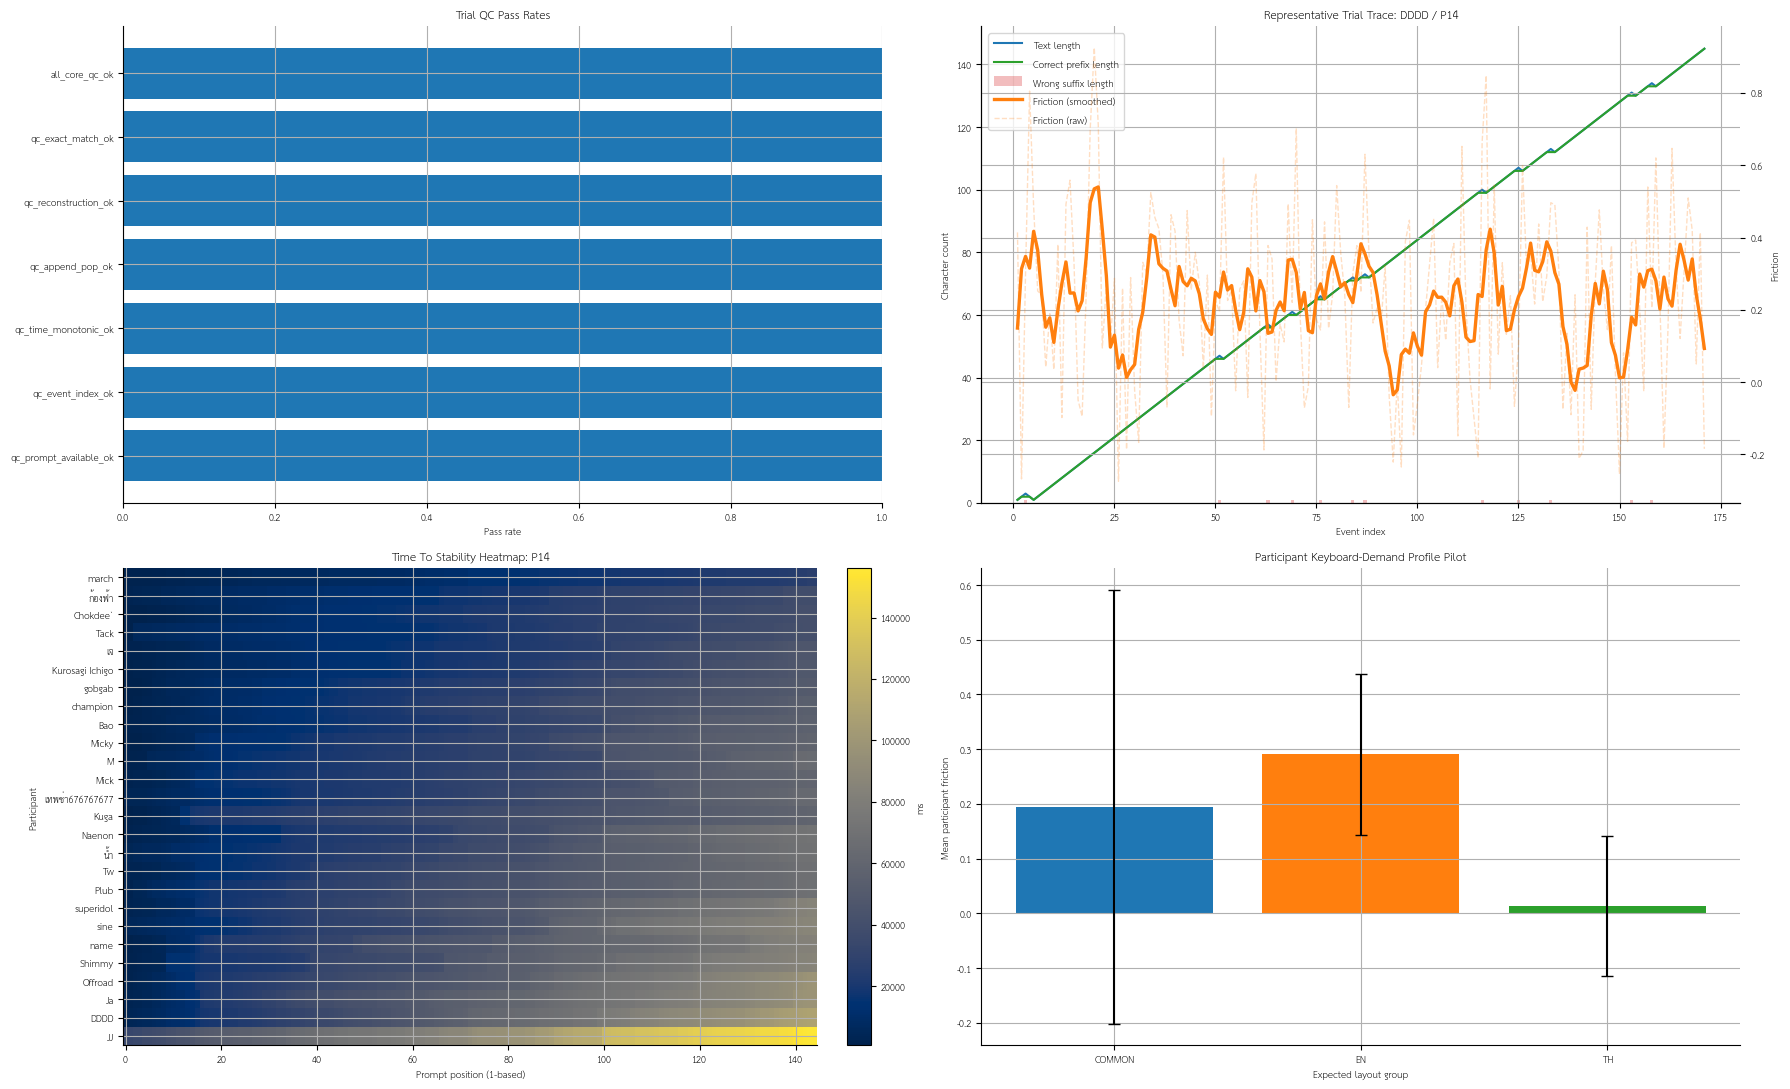

In [19]:
def choose_example_trial(trial_features: pd.DataFrame, preferred_prompt_id: str = SELECTED_PILOT_PROMPT_ID) -> pd.Series:
    candidate_masks = [
        trial_features["prompt_id"].eq(preferred_prompt_id) & trial_features["qc_exact_match_ok"].eq(1),
        trial_features["prompt_id"].eq(preferred_prompt_id),
        trial_features["qc_exact_match_ok"].eq(1),
        pd.Series(True, index=trial_features.index),
    ]

    for mask in candidate_masks:
        subset = trial_features.loc[mask].sort_values("event_count").reset_index(drop=True)
        if not subset.empty:
            return subset.iloc[len(subset) // 2]

    raise ValueError("No trial available for pilot visualization.")


example_trial = choose_example_trial(trial_features, preferred_prompt_id=SELECTED_PILOT_PROMPT_ID)
example_events = event_enriched.loc[event_enriched["trial_uid"].eq(example_trial["trial_uid"])].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

qc_rate_columns = [
    "qc_prompt_available_ok",
    "qc_event_index_ok",
    "qc_time_monotonic_ok",
    "qc_append_pop_ok",
    "qc_reconstruction_ok",
    "qc_exact_match_ok",
    "all_core_qc_ok",
]
qc_rates = trial_qc[qc_rate_columns].mean().sort_values()
axes[0, 0].barh(qc_rates.index, qc_rates.values, color="tab:blue")
axes[0, 0].set_xlim(0, 1)
axes[0, 0].set_title("Trial QC Pass Rates")
axes[0, 0].set_xlabel("Pass rate")

axes[0, 1].plot(example_events["event_index"], example_events["text_after_length_actual"], label="Text length", color="tab:blue")
axes[0, 1].plot(example_events["event_index"], example_events["prefix_match_len_after"], label="Correct prefix length", color="tab:green")
axes[0, 1].bar(
    example_events["event_index"],
    example_events["error_suffix_len_after"],
    label="Wrong suffix length",
    color="tab:red",
    alpha=0.3,
)
axis_right = axes[0, 1].twinx()

axis_right.plot(
    example_events["event_index"],
    example_events["friction_plot_smooth"],
    label="Friction (smoothed)",
    color="tab:orange",
    linewidth=2.4,
)
axis_right.plot(
    example_events["event_index"],
    example_events["friction"],
    label="Friction (raw)",
    color="tab:orange",
    alpha=0.25,
    linewidth=1.0,
    linestyle="--",
)
axes[0, 1].set_title(
    f"Representative Trial Trace: {example_trial['participant_code']} / {example_trial['prompt_id']}"
)
axes[0, 1].set_xlabel("Event index")
axes[0, 1].set_ylabel("Character count")
axis_right.set_ylabel("Friction")
left_handles, left_labels = axes[0, 1].get_legend_handles_labels()
right_handles, right_labels = axis_right.get_legend_handles_labels()
axes[0, 1].legend(left_handles + right_handles, left_labels + right_labels, loc="upper left")

heatmap = (
    prompt_position_features.loc[prompt_position_features["prompt_id"].eq(SELECTED_PILOT_PROMPT_ID)]
    .pivot(index="participant_code", columns="prompt_position_1based", values="time_to_stability_ms")
)
if not heatmap.empty:
    heatmap = heatmap.loc[heatmap.mean(axis=1).sort_values().index]
    image = axes[1, 0].imshow(heatmap.to_numpy(dtype=float), aspect="auto", cmap="cividis")
    axes[1, 0].set_title(f"Time To Stability Heatmap: {SELECTED_PILOT_PROMPT_ID}")
    axes[1, 0].set_xlabel("Prompt position (1-based)")
    axes[1, 0].set_ylabel("Participant")
    axes[1, 0].set_yticks(range(len(heatmap.index)))
    axes[1, 0].set_yticklabels(heatmap.index.tolist())
    fig.colorbar(image, ax=axes[1, 0], fraction=0.046, pad=0.04, label="ms")
else:
    axes[1, 0].text(0.5, 0.5, "No prompt-position data available.", ha="center", va="center")
    axes[1, 0].set_axis_off()

layout_profile_plot = participant_keyboard_profile.loc[
    participant_keyboard_profile["profile_dimension"].eq("expected_layout")
    & participant_keyboard_profile["profile_value"].ne("<missing>")
].copy()
if not layout_profile_plot.empty:
    layout_profile_plot = (
        layout_profile_plot.groupby("profile_value")
        .agg(
            mean_of_participant_mean_friction=("mean_friction", "mean"),
            std_of_participant_mean_friction=("mean_friction", "std"),
            participants=("participant_code", "nunique"),
        )
        .reset_index()
        .sort_values("profile_value")
    )
    axes[1, 1].bar(
        layout_profile_plot["profile_value"],
        layout_profile_plot["mean_of_participant_mean_friction"],
        yerr=layout_profile_plot["std_of_participant_mean_friction"].fillna(0),
        color=["tab:blue", "tab:orange", "tab:green"][: len(layout_profile_plot)],
        capsize=4,
    )
    axes[1, 1].set_title("Participant Keyboard-Demand Profile Pilot")
    axes[1, 1].set_xlabel("Expected layout group")
    axes[1, 1].set_ylabel("Mean participant friction")
else:
    axes[1, 1].text(0.5, 0.5, "No participant profile data available.", ha="center", va="center")
    axes[1, 1].set_axis_off()


plt.tight_layout()
pilot_participant_label = str(example_trial["participant_code"]).replace(" ", "_")
pilot_figure_path = PILOT_FIGURE_DIR / f"pilot_trace_{example_trial['prompt_id']}_{pilot_participant_label}.png"
fig.savefig(pilot_figure_path, dpi=200, bbox_inches="tight")
print(f"Saved pilot figure to {pilot_figure_path}")
plt.show()


In [20]:
transformation_summary = pd.DataFrame(
    [
        {"output": "event_sequence_enriched", "rows": len(event_enriched)},
        {"output": "prompt_position_features", "rows": len(prompt_position_features)},
        {"output": "trial_features", "rows": len(trial_features)},
        {"output": "participant_keyboard_profile", "rows": len(participant_keyboard_profile)},
        {"output": "error_episode_summary", "rows": len(error_episode_summary)},
    ]
)

print(f"Output directory: {OUTPUT_DIR}")
display(transformation_summary)
display(export_manifest)


Output directory: /Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_pilot_visualization


,output,rows
0,event_sequence_enriched,30930
1,prompt_position_features,23374
2,trial_features,390
3,participant_keyboard_profile,832
4,error_episode_summary,1889


,table,rows,csv_path,parquet_path
0,char_map_resolution_audit,177,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
1,keyboard_distance_lookup,2304,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
2,prompt_character_reference,899,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
3,event_sequence_enriched,30930,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
4,event_sequence_core,30930,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
5,error_episode_summary,1889,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
6,prompt_position_features,23374,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
7,prompt_position_sequence_ready,23374,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
8,trial_qc,390,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
9,session_qc,26,/Users/kongfha/Desktop/Time_Series_Mining/Final Project/Typing-Behavior-Time-Series-Analysis/outputs/01_time_series_transformation_and_p...,
